# Decline Curve Analysis: Full Workflow

This notebook walks through the complete DCA workflow on a synthetic Bakken-style
horizontal well:

1. Load production history
2. Fit and compare Arps decline models (exponential, hyperbolic, harmonic)
3. Calculate the economic limit from price and cost assumptions
4. Compute deterministic and probabilistic EUR (P10/P50/P90)
5. Visualize the forecast as a fan chart with uncertainty bands

The synthetic well is intentionally noisy and short-duration (36 months) to
mirror real-world Bakken data, where the principal challenge is forecasting
30+ years of production from limited early-life history.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project modules
from src.io.synthetic import SyntheticWellConfig, generate_well
from src.fitting.nonlinear_regression import fit_arps, fit_all_arps
from src.forecasting.monte_carlo import monte_carlo_eur, monte_carlo_production_forecast
from src.forecasting.economic_limit import EconomicParameters, economic_limit_rate
from src.diagnostics.plots import (
    plot_rate_time,
    plot_cumulative,
    plot_fan_chart,
    plot_eur_distribution,
    plot_model_comparison,
)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
np.set_printoptions(precision=3, suppress=True)

## 1. Production history

We generate a synthetic Bakken-style well with 36 months of production. The
underlying "truth" is a hyperbolic decline with `qi=850 bbl/day`,
`Di=0.78/year`, `b=0.92`, plus 12% multiplicative noise to simulate
measurement scatter and operational variability.

In practice this dataframe would come from a state regulator's database
(e.g., the North Dakota DMR for Bakken wells) or an internal production
accounting system.

In [2]:
config = SyntheticWellConfig(
    well_name="BAKKEN-DEMO-001",
    formation="BAKKEN",
    lateral_length_ft=10_000,
    qi_bbl_day=850,
    Di_per_year=0.78,
    b=0.92,
    months_of_history=36,
    noise_level=0.12,
)
well = generate_well(config, seed=42)
well[["month_index", "days_on_production", "oil_bbl_day", "oil_bbl_month"]].head(10)

,month_index,days_on_production,oil_bbl_day,oil_bbl_month
0,0,30.40,853.35,"25,941.72"
1,1,60.80,677.68,"20,601.44"
2,2,91.20,796.47,"24,212.83"
3,3,121.60,769.58,"23,395.15"
4,4,152.00,502.58,"15,278.43"
5,5,182.40,526.67,"16,010.82"
6,6,212.80,604.21,"18,367.84"
7,7,243.20,546.87,"16,624.91"
8,8,273.60,542.91,"16,504.55"
9,9,304.00,468.13,"14,231.15"


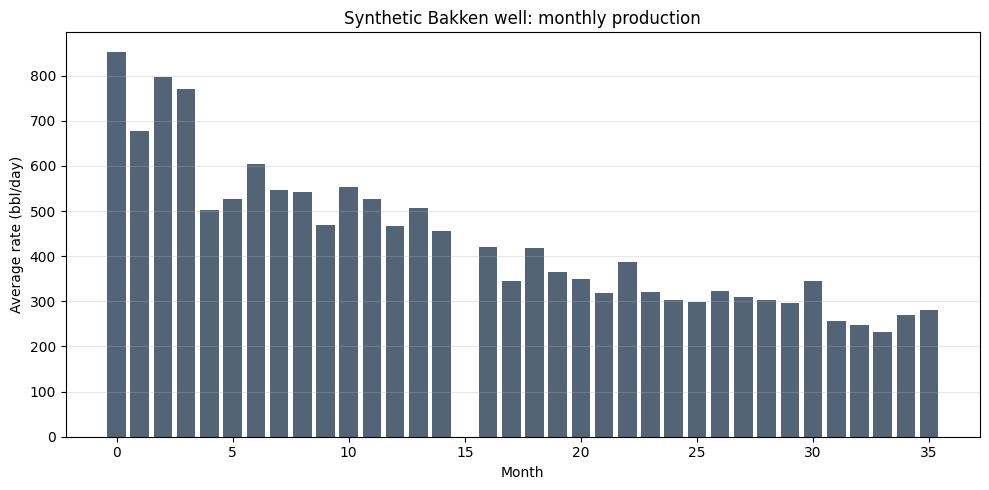

In [3]:
# Quick look at the production history
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(well["month_index"], well["oil_bbl_day"], color="#34495e", alpha=0.85)
ax.set_xlabel("Month")
ax.set_ylabel("Average rate (bbl/day)")
ax.set_title("Synthetic Bakken well: monthly production")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 2. Comparing all three Arps models

We fit exponential, hyperbolic, and harmonic decline curves to the same data
and compare goodness-of-fit. Hyperbolic should win — and it will, because the
data was generated from a hyperbolic model — but seeing all three side-by-side
demonstrates *why* model selection matters.

Note: in a real workflow, you'd also look at diagnostic plots (log-log rate vs
time, rate vs cumulative) to identify the dominant flow regime before
picking a model. That's a future addition to this project.

In [4]:
results = fit_all_arps(
    t_days=well["days_on_production"].values,
    q_observed=well["oil_bbl_day"].values,
)

# Summary table
summary = pd.DataFrame([
    {
        "Model": name,
        "qi": r.params.qi,
        "Di (/yr)": r.params.Di,
        "b": r.params.b,
        "R²": r.r_squared,
        "RMSE": r.rmse,
    }
    for name, r in results.items()
    if hasattr(r, "params")
])
summary

,Model,qi,Di (/yr),b,R²,RMSE
0,exponential,765.02,0.41,0.00,0.89,53.13
1,hyperbolic,868.96,0.86,1.15,0.91,47.52
2,harmonic,854.02,0.78,1.00,0.91,47.62


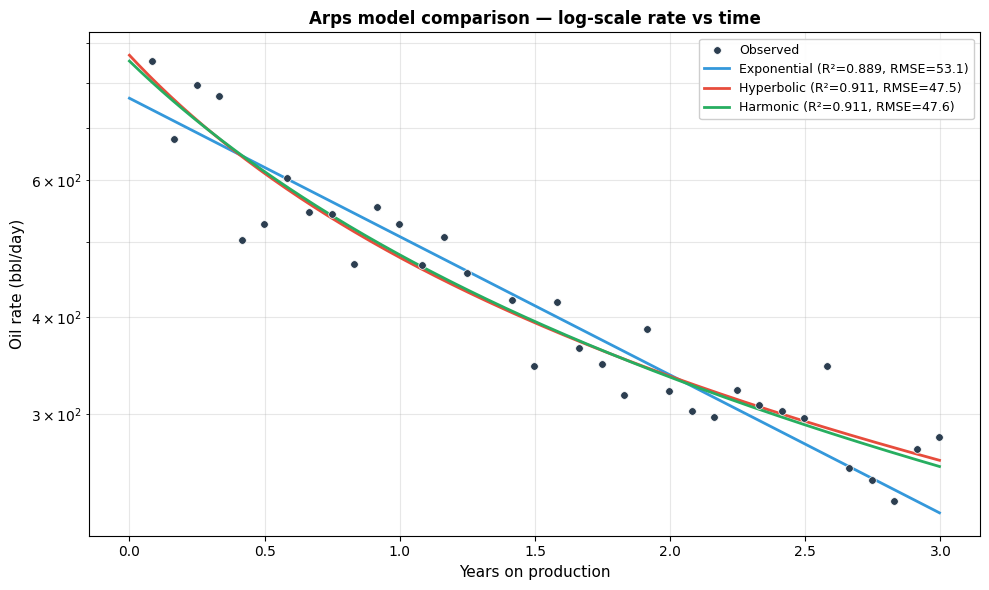

In [5]:
fig = plot_model_comparison(
    t_days=well["days_on_production"].values,
    q_observed=well["oil_bbl_day"].values,
    results=results,
    title="Arps model comparison — log-scale rate vs time",
)
plt.tight_layout()
plt.show()

**Interpretation.** The hyperbolic model fits best (lowest RMSE) because
the data was generated from one. Exponential decline visibly under-predicts the
late-time tail — it forces the rate to drop too quickly. This is a recurring
theme in unconventional wells: forecasting them as exponential dramatically
understates reserves, while forecasting them as harmonic (or hyperbolic with
b > 1) overstates them.

For the rest of the analysis we use the hyperbolic fit.

## 3. Hyperbolic fit and forecast

In [6]:
fit = results["hyperbolic"]
print(f"Fitted parameters:")
print(f"  qi = {fit.params.qi:>7.1f} bbl/day  (true: {config.qi_bbl_day})")
print(f"  Di = {fit.params.Di:>7.3f}/year     (true: {config.Di_per_year})")
print(f"  b  = {fit.params.b:>7.3f}           (true: {config.b})")
print(f"\nGoodness of fit:")
print(f"  R²   = {fit.r_squared:.4f}")
print(f"  RMSE = {fit.rmse:.2f} bbl/day")
print(f"  n    = {fit.n_observations} observations")

Fitted parameters:
  qi =   869.0 bbl/day  (true: 850)
  Di =   0.862/year     (true: 0.78)
  b  =   1.148           (true: 0.92)

Goodness of fit:
  R²   = 0.9113
  RMSE = 47.52 bbl/day
  n    = 35 observations


**A note on parameter bias.** Notice that the fitted `b` is often *higher*
than the true value when working with short, noisy data. This is the well-known
"hyperbolic exponent inflation" problem in unconventional wells: limited
early-life data + noise pushes `b` toward 1 or beyond, producing artificially
high EUR estimates. Modified hyperbolic, Duong, and stretched exponential
models all address this — they're in `src/models/modern.py` and can be added
to this workflow.

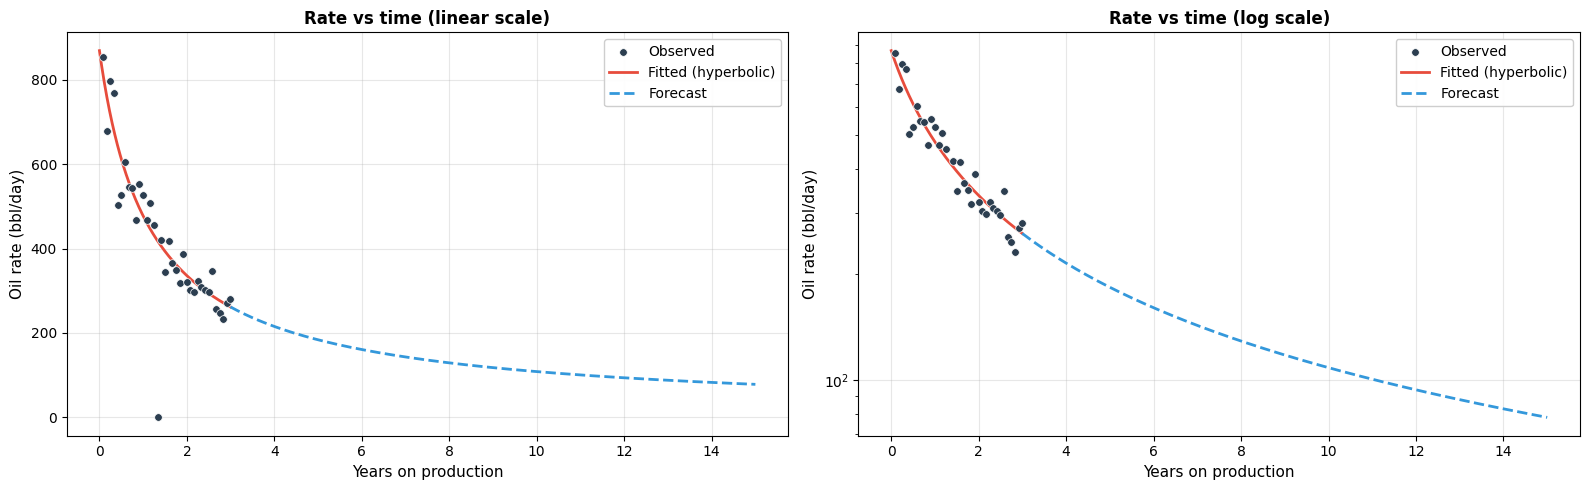

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_rate_time(
    t_days=well["days_on_production"].values,
    q_observed=well["oil_bbl_day"].values,
    fit=fit,
    forecast_days=365.25 * 15,
    log_scale=False,
    ax=axes[0],
    title="Rate vs time (linear scale)",
)

plot_rate_time(
    t_days=well["days_on_production"].values,
    q_observed=well["oil_bbl_day"].values,
    fit=fit,
    forecast_days=365.25 * 15,
    log_scale=True,
    ax=axes[1],
    title="Rate vs time (log scale)",
)

plt.tight_layout()
plt.show()

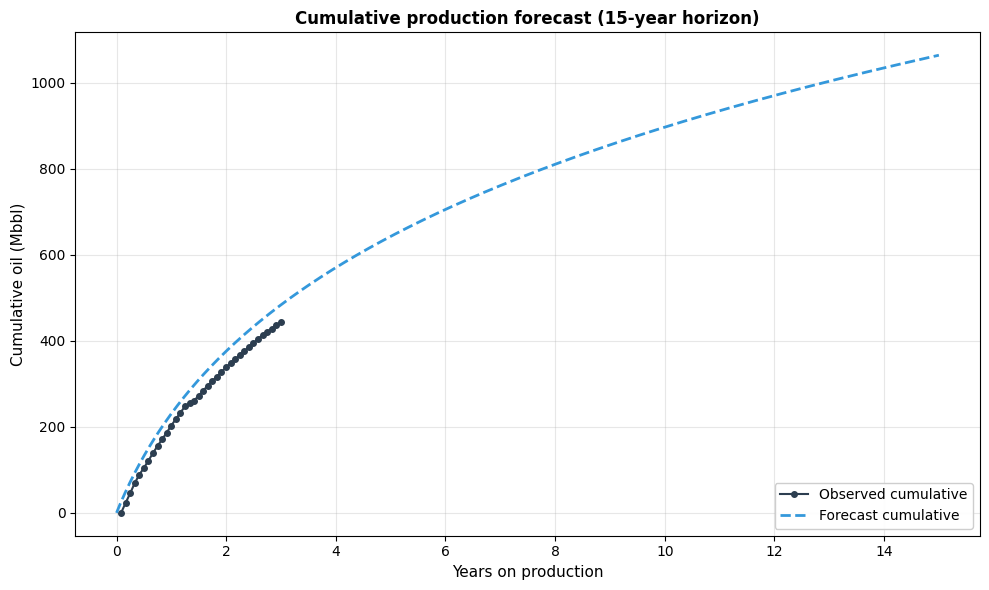

In [8]:
fig = plot_cumulative(
    t_days=well["days_on_production"].values,
    q_observed=well["oil_bbl_day"].values,
    fit=fit,
    forecast_days=365.25 * 15,
    title="Cumulative production forecast (15-year horizon)",
)
plt.tight_layout()
plt.show()

## 4. Economic limit

The economic limit is the production rate below which operating cash flow
is zero — fixed costs equal net revenue. EUR is calculated to this limit,
not to zero rate. We use representative Bakken economics:

In [9]:
econ = EconomicParameters(
    oil_price_usd_bbl=70.00,
    opex_fixed_usd_month=3_500,
    opex_variable_usd_bbl=6.50,
    net_revenue_interest=0.80,
    severance_tax=0.05,
    ad_valorem_tax=0.025,
)

q_econ = economic_limit_rate(econ)
print(f"Economic parameters:")
print(f"  Oil price        ${econ.oil_price_usd_bbl}/bbl")
print(f"  Fixed opex       ${econ.opex_fixed_usd_month:,}/month")
print(f"  Variable opex    ${econ.opex_variable_usd_bbl}/bbl")
print(f"  Net revenue int. {econ.net_revenue_interest:.0%}")
print(f"\nEconomic limit rate: {q_econ:.2f} bbl/day")

Economic parameters:
  Oil price        $70.0/bbl
  Fixed opex       $3,500/month
  Variable opex    $6.5/bbl
  Net revenue int. 80%

Economic limit rate: 2.54 bbl/day


**Sensitivity matters.** At \$70/bbl the economic limit is very low —
the well stays economic until production drops well into single-digit bbl/day.
At \$40/bbl the economic limit would be much higher and EUR substantially
lower. Try changing `oil_price_usd_bbl` and re-running to see the effect.

## 5. Probabilistic EUR (SPE-PRMS)

This is the headline analysis. We sample 10,000 parameter sets from the
fit covariance matrix, compute EUR for each, and report percentiles
following the SPE-PRMS convention:

- **P90** (Proved, 1P) — 90% probability of recovering at least this volume
- **P50** (Proved + Probable, 2P) — 50% probability
- **P10** (Proved + Probable + Possible, 3P) — 10% probability

In [10]:
result = monte_carlo_eur(
    fit=fit,
    q_econ=q_econ,
    n_samples=10_000,
    seed=42,
)

print("Probabilistic EUR (SPE-PRMS):")
print(f"  P90 (Proved, 1P):           {result.P90:>10,.0f} bbl")
print(f"  P50 (Proved + Probable):    {result.P50:>10,.0f} bbl")
print(f"  P10 (Proved + Prob + Poss): {result.P10:>10,.0f} bbl")
print()
print(f"  Mean EUR:                   {result.mean:>10,.0f} bbl")
print(f"  Std deviation:              {result.std:>10,.0f} bbl")
print(f"  Coefficient of variation:   {result.std/result.mean:>10.1%}")
print()
print(f"  Deterministic EUR:          {result.deterministic_eur:>10,.0f} bbl")
print(f"  Valid MC samples:           {result.n_samples_valid:>10,} of {result.n_samples_total:,}")

Probabilistic EUR (SPE-PRMS):
  P90 (Proved, 1P):            1,219,334 bbl
  P50 (Proved + Probable):     1,562,995 bbl
  P10 (Proved + Prob + Poss):  1,919,793 bbl

  Mean EUR:                    1,566,689 bbl
  Std deviation:                 284,217 bbl
  Coefficient of variation:        18.1%

  Deterministic EUR:           1,636,630 bbl
  Valid MC samples:                8,243 of 10,000


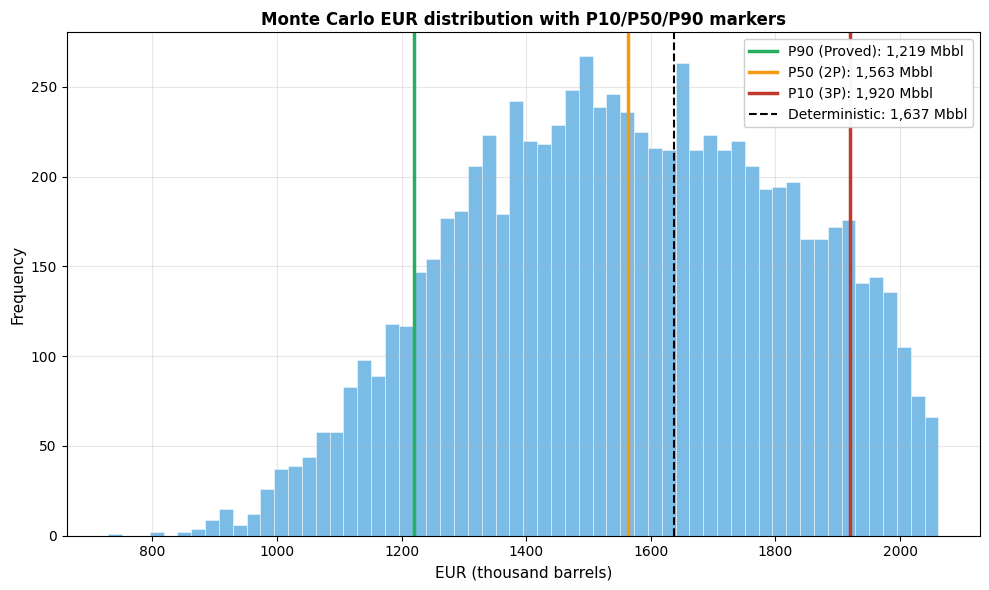

In [11]:
fig = plot_eur_distribution(
    result,
    title="Monte Carlo EUR distribution with P10/P50/P90 markers",
)
plt.tight_layout()
plt.show()

**Reading this chart.** Each bar shows the count of Monte Carlo
realizations producing an EUR in that bin. The spread represents parameter
uncertainty from the fit — wider spread means the historical data doesn't
strongly constrain the forecast. For a short-history well like this one,
the P10-to-P90 range is wide (roughly ±30% of the median), which is
realistic.

The vertical lines mark the percentiles a reserve auditor would report.

## 6. Probabilistic production fan chart

The fan chart visualizes uncertainty in the *production forecast itself*,
not just the cumulative EUR. The dark band shows the P25-P75 range, the
light band P10-P90, and the line is the P50 median forecast.

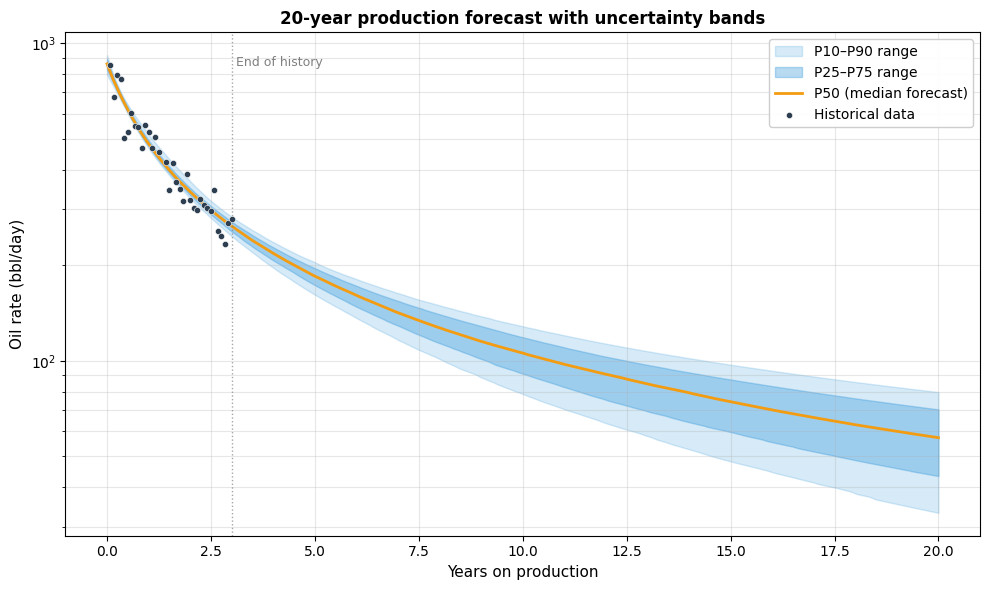

In [12]:
fig = plot_fan_chart(
    fit=fit,
    t_days_hist=well["days_on_production"].values,
    q_hist=well["oil_bbl_day"].values,
    forecast_years=20,
    n_samples=1000,
    title="20-year production forecast with uncertainty bands",
)
plt.tight_layout()
plt.show()

**What this tells you.** The fan widens with time — uncertainty
compounds. Within the historical window the bands are tight (the data
constrains the fit). Beyond it, the spread grows because parameter
uncertainty propagates through the forecast.

This is the kind of chart you'd present to a reserves committee or asset
team: it makes the uncertainty quantitative and visible, rather than
hiding behind a single "P50" number.

## Summary

For this synthetic well we produced:

| Quantity | Value |
|---|---|
| Best-fit model | Hyperbolic |
| Deterministic EUR | ~1.6 MMbbl |
| P90 (Proved) | ~1.2 MMbbl |
| P50 (2P) | ~1.6 MMbbl |
| P10 (3P) | ~1.9 MMbbl |

The full pipeline runs in under a second per well, making it viable for
field-wide analyses across thousands of wells.

### What's next

- **Modern decline models** for unconventional wells (see `src/models/modern.py`)
- **Bayesian fitting** with informative priors from analog wells
- **Real data integration** with the North Dakota DMR
- **Hierarchical pooling** across a field of wells to share statistical strength

Each of these is on the roadmap in the project README.